# Detection delay simulation

Average detection delay of `GridDetector` with `MeanCUSUM` as a function of
the post-change signal strength. The threshold is calibrated to a target
false alarm probability over a stream of length $T$, and for a range of
mean shifts we simulate null-then-shifted streams (changepoint at the
middle of the stream) and record the detection delay and detection power.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from gridcp import GridDetector
from gridcp.calibration import (
    calibrate_threshold_false_alarm,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import MeanCUSUM

## Simulation parameters

In [2]:
ALPHA = 0.05        # Target false alarm probability over stream
STREAM_LEN = 1000   # Stream length (T)
CHANGEPOINT = 500   # First post-change index
N_CAL = 10_000      # Paths for threshold calibration
N_SIM = 5_000       # Paths per shift for delay estimation
SHIFTS = np.round(np.arange(0.0, 4.01, 0.125), 2)  # 0.0, 0.125, ..., 4.0
MAX_DELAY = STREAM_LEN - CHANGEPOINT               # Maximum possible detection delay

score = MeanCUSUM()
detector = GridDetector(score=score)
pre_sampler = lambda rng: rng.standard_normal()

## Calibrate threshold

In [3]:
start_time = time.perf_counter()
threshold = calibrate_threshold_false_alarm(
    score,
    false_alarm_probability=ALPHA,
    n_paths=N_CAL,
    stream_len=STREAM_LEN,
    pre_sampler=pre_sampler,
    rng=0,
)
detector_cal = with_calibrated_threshold(detector, threshold)
print(
    f"Calibrated threshold: {threshold[0]:.4f}"
    f"  ({time.perf_counter() - start_time:.1f}s)"
)

Calibrated threshold: 3.0219  (9.2s)


## Simulate detection delay across signal strengths

In [4]:
median_delays = []
mean_delays = []
power = []

for i, shift in enumerate(SHIFTS):
    t0 = time.perf_counter()
    post_sampler = lambda rng, s=shift: rng.standard_normal() + s
    alarm_times = mc_alarm_times(
        detector_cal,
        N_SIM,
        STREAM_LEN,
        pre_sampler=pre_sampler,
        post_sampler=post_sampler,
        changepoint=CHANGEPOINT,
        rng=i + 1,
    )

    # Ignore false alarms (pre-changepoint). Among the remaining paths, detected
    # ones contribute their delay; non-detecting ones are censored at MAX_DELAY.
    false_alarm = alarm_times < CHANGEPOINT
    detected = (alarm_times >= CHANGEPOINT) & (alarm_times < STREAM_LEN)
    kept = ~false_alarm
    delays = np.where(detected[kept], alarm_times[kept] - CHANGEPOINT, MAX_DELAY)

    med = float(np.median(delays)) if delays.size > 0 else np.nan
    mn = float(np.mean(delays)) if delays.size > 0 else np.nan
    pwr = float(np.mean(detected))

    median_delays.append(med)
    mean_delays.append(mn)
    power.append(pwr)

    print(
        f"shift={shift:.2f}  median_delay={med:6.1f}  mean_delay={mn:6.1f}  "
        f"power={pwr:.3f}  ({time.perf_counter() - t0:.1f}s)"
    )

median_delays = np.array(median_delays)
mean_delays = np.array(mean_delays)
power = np.array(power)
print(f"Total simulation time: {time.perf_counter() - start_time:.1f}s")

np.savez(
    "simulation_results/dd_sim_results.npz",
    shifts=SHIFTS,
    median_delays=median_delays,
    mean_delays=mean_delays,
    power=power,
    threshold=threshold,
    alpha=np.float64(ALPHA),
    stream_len=np.int64(STREAM_LEN),
    changepoint=np.int64(CHANGEPOINT),
    n_cal=np.int64(N_CAL),
    n_sim=np.int64(N_SIM),
)
print("Saved results to simulation_results/dd_sim_results.npz")

shift=0.00  median_delay= 500.0  mean_delay= 499.9  power=0.000  (4.6s)
shift=0.12  median_delay= 500.0  mean_delay= 499.7  power=0.001  (4.6s)
shift=0.25  median_delay= 500.0  mean_delay= 482.5  power=0.088  (4.6s)
shift=0.38  median_delay= 320.0  mean_delay= 326.4  power=0.695  (4.2s)
shift=0.50  median_delay= 145.0  mean_delay= 159.7  power=0.943  (3.5s)
shift=0.62  median_delay=  87.0  mean_delay=  93.0  power=0.947  (3.3s)
shift=0.75  median_delay=  53.0  mean_delay=  58.8  power=0.944  (3.0s)
shift=0.88  median_delay=  37.0  mean_delay=  40.0  power=0.951  (2.9s)
shift=1.00  median_delay=  28.0  mean_delay=  29.9  power=0.951  (2.9s)
shift=1.12  median_delay=  23.0  mean_delay=  23.8  power=0.953  (2.9s)
shift=1.25  median_delay=  18.0  mean_delay=  18.9  power=0.947  (2.8s)
shift=1.38  median_delay=  14.0  mean_delay=  15.3  power=0.949  (3.1s)
shift=1.50  median_delay=  12.0  mean_delay=  12.9  power=0.948  (3.0s)
shift=1.62  median_delay=  10.0  mean_delay=  10.9  power=0.950 

## Average detection delay vs signal strength

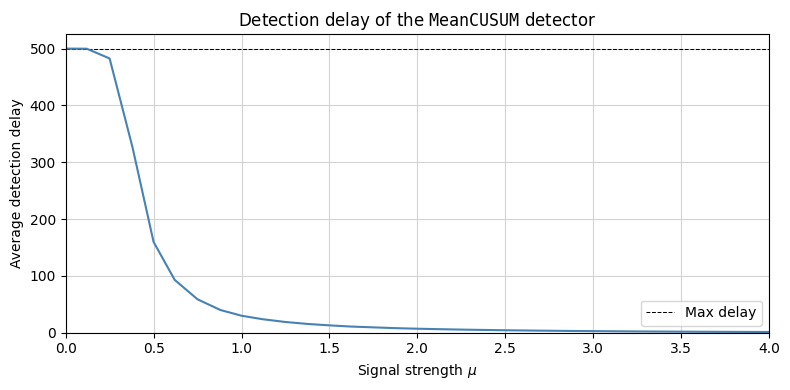

In [ ]:
data = np.load("simulation_results/dd_sim_results.npz")
shifts = data["shifts"]
mean_delays = data["mean_delays"]
median_delays = data["median_delays"]
power = data["power"]
ALPHA = float(data["alpha"])
STREAM_LEN = int(data["stream_len"])
CHANGEPOINT = int(data["changepoint"])
MAX_DELAY = STREAM_LEN - CHANGEPOINT

fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(MAX_DELAY, color="k", linestyle="--", linewidth=0.75, label="Max delay")
ax.plot(shifts, mean_delays, color="steelblue")
ax.set_xlabel(r"Signal strength $\mu$")
ax.set_ylabel("Average detection delay")
ax.set_title(r"Detection delay of the $\mathtt{MeanCUSUM}$ detector")
ax.set_xlim(shifts.min(), shifts.max())
ax.set_ylim(0, MAX_DELAY * 1.05)
ax.grid(True, color="lightgray", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()
#plt.savefig("dd_sim.pdf", bbox_inches="tight")
plt.show()